In [2]:
import pandas as pd
import seaborn as sns

df = pd.read_csv('Titanic-Dataset.csv')

### Ask 7 questions!

# Q 1. How big the data?

In [3]:
df.shape

(891, 12)

# Q 2. How does the data look like?

In [4]:
# df.head()    #sometimes it can be biased so use sample to get random rows from the dataset
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
384,385,0,3,"Plotcharsky, Mr. Vasil",male,NaN,0,0,349227,7.8958,NaN,S
307,308,1,1,"Penasco y Castellana, Mrs. Victor de Satode (M...",female,17.0,1,0,PC 17758,108.9000,C65,C
199,200,0,2,"Yrois, Miss. Henriette (""Mrs Harbeck"")",female,24.0,0,0,248747,13.0000,NaN,S
323,324,1,2,"Caldwell, Mrs. Albert Francis (Sylvia Mae Harb...",female,22.0,1,1,248738,29.0000,NaN,S
385,386,0,2,"Davies, Mr. Charles Henry",male,18.0,0,0,S.O.C. 14879,73.5000,NaN,S


# Q 3. What is the datatype of columns?

In [5]:
df.info() #gives info about the dataset like datatypes, null values, memory usage, columns etc.

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# Q. 4 Are there any missing values?

In [6]:
df.isnull().sum() 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Q 5. How does the data look like mathematically?

In [7]:
df.describe() #gives mathematical description of the dataset like mean, median, std deviation, min, max etc.

#useful to detect outliers, anomalies, and understand the distribution of the data.

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Q 6. Are there any duplicate values?

In [8]:
df.duplicated().sum() 

np.int64(0)

# Q 7. What is the correlation between columns?

In [9]:
# df.corr()  It doesnt work if string datatype is present
df.corr(numeric_only=True) 

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [10]:
df.corr(numeric_only=True)['Survived']  #more the positive more the correlation

PassengerId   -0.005007
Survived       1.000000
Pclass        -0.338481
Age           -0.077221
SibSp         -0.035322
Parch          0.081629
Fare           0.257307
Name: Survived, dtype: float64

# EDA 

## 1. Categorical Data

Countplot

In [11]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Pclass', ylabel='count'>

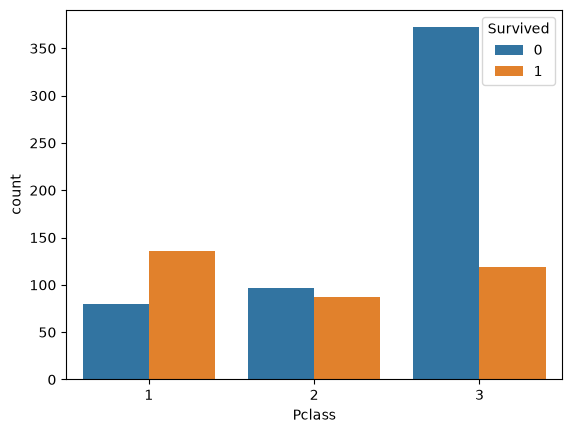

In [12]:
sns.countplot(x=df['Pclass'], hue=df['Survived'])  #hue is used to separate the data based on the survived column

b. Pie Chart

<Axes: >

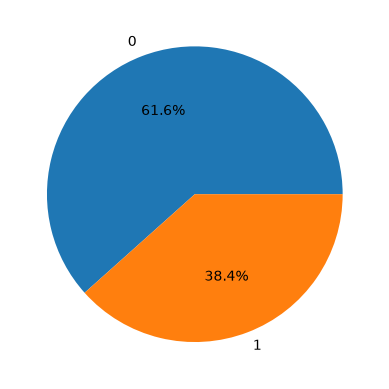

In [13]:
df['Survived'].value_counts().plot(kind = 'pie', autopct='%1.1f%%')  #autopct is used to show the percentage of each category in the pie chart

## 2. Numerical Data

### a. Histogram

(array([40., 14., 15., 31., 79., 98., 85., 84., 73., 45., 35., 35., 29.,
        16., 13., 11.,  4.,  5.,  1.,  1.]),
 array([ 0.42 ,  4.399,  8.378, 12.357, 16.336, 20.315, 24.294, 28.273,
        32.252, 36.231, 40.21 , 44.189, 48.168, 52.147, 56.126, 60.105,
        64.084, 68.063, 72.042, 76.021, 80.   ]),
 <BarContainer object of 20 artists>)

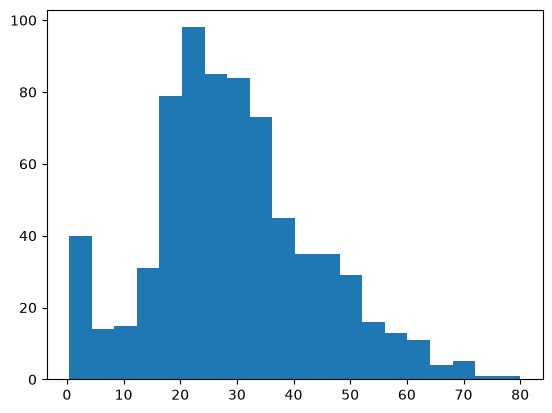

In [14]:
import matplotlib.pyplot as plt
plt.hist(df['Age'], bins=20)  #bins is used to divide the data into equal parts

### b. DistPlot (distribution plot)

/tmp/ipykernel_11407/3219440379.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'].dropna(), bins=20)  #dropna is used to remove the null values from the dataset


<Axes: xlabel='Age', ylabel='Density'>

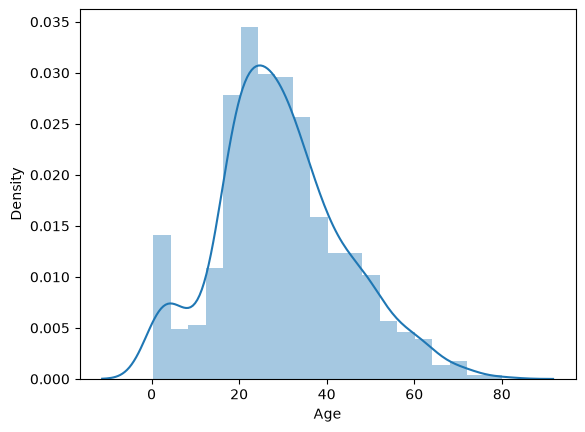

In [15]:
sns.distplot(df['Age'].dropna(), bins=20)  #dropna is used to remove the null values from the dataset

#here the curve is kde (kernel density estimation) which is used to estimate the probability density function of a continuous random variable. 
# It is a way to visualize the distribution of the data.

### c. Boxplot

<Axes: xlabel='Pclass', ylabel='Age'>

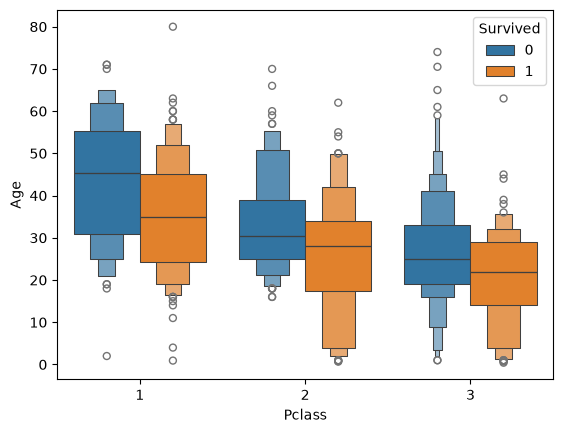

In [16]:
sns.boxenplot(x=df['Pclass'], y=df['Age'], hue=df['Survived'])  #boxenplot is used to visualize the distribution of the data and it is similar to boxplot but it is more robust to outliers
# tells the ouliers, used in .dropna(), bins=20isualization

In [17]:
df['Age'].min()
df['Age'].max()

np.float64(80.0)